# Solutions: Notebook 01 — Quantile Regression Fundamentals

Complete solutions for all six exercises from the main notebook.

In [1]:
# Setup (same as main notebook)
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from panelbox import PooledOLS
from panelbox.models.quantile import PooledQuantile

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
np.random.seed(42)

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

# Load data
data = pd.read_csv(DATA_DIR / "card_education.csv")

# Prepare arrays
y = data["lwage"].values
var_names = ["const", "educ", "exper", "exper_sq"]
X = np.column_stack(
    [np.ones(len(data)), data["educ"].values, data["exper"].values, data["exper"].values ** 2]
)
entity_id = data["id"].values

# OLS baseline
ols_model = PooledOLS("lwage ~ educ + exper + I(exper**2)", data, entity_col="id", time_col="year")
ols_result = ols_model.fit(cov_type="clustered")


def check_loss(u, tau):
    return u * (tau - (u < 0).astype(float))


print("Setup complete.")

Setup complete.


---

## Exercise 1: Conceptual Understanding (Easy)

**Question**: Why is the check loss function asymmetric? What would happen if we used symmetric loss for quantile estimation?

In [2]:
# SOLUTION: Conceptual answer + numerical verification

# ANSWER:
# The check loss is asymmetric because quantiles (except the median) are NOT
# at the center of the distribution. To estimate the tau-th quantile, the
# loss must penalize errors on one side more than the other:
#   - For tau=0.9: we want 90% of data BELOW the estimate. Under-prediction
#     (positive residuals) must be penalized MORE to push the estimate upward.
#   - For tau=0.1: we want 10% of data BELOW. Over-prediction (negative residuals)
#     must be penalized MORE to push the estimate downward.
#
# If we used symmetric loss:
#   - Squared loss always gives the MEAN (regardless of tau)
#   - Symmetric absolute loss always gives the MEDIAN
#   - Neither can target other quantiles

# NUMERICAL VERIFICATION:
np.random.seed(42)
sample = np.random.exponential(scale=5, size=1000)  # Right-skewed

# For tau=0.25, the check loss should be minimized at Q(0.25)
candidates = np.linspace(0, 15, 1000)
tau = 0.25

losses_check = [np.sum(check_loss(sample - c, tau)) for c in candidates]
losses_squared = [np.sum((sample - c) ** 2) for c in candidates]
losses_abs = [np.sum(np.abs(sample - c)) for c in candidates]

min_check = candidates[np.argmin(losses_check)]
min_squared = candidates[np.argmin(losses_squared)]
min_abs = candidates[np.argmin(losses_abs)]

print("Minimizers of different loss functions:")
print(f"  Check loss (tau=0.25): {min_check:.3f}  (true Q(0.25) = {np.quantile(sample, 0.25):.3f})")
print(f"  Squared loss:         {min_squared:.3f}  (true mean   = {np.mean(sample):.3f})")
print(f"  Absolute loss:        {min_abs:.3f}  (true median = {np.median(sample):.3f})")
print()
print("=> Symmetric losses cannot target the 25th percentile.")
print("   Only the asymmetric check loss can target arbitrary quantiles.")

Minimizers of different loss functions:
  Check loss (tau=0.25): 1.321  (true Q(0.25) = 1.346)
  Squared loss:         4.865  (true mean   = 4.863)
  Absolute loss:        3.438  (true median = 3.434)

=> Symmetric losses cannot target the 25th percentile.
   Only the asymmetric check loss can target arbitrary quantiles.


---

## Exercise 2: Coefficient Path for Experience (Easy)

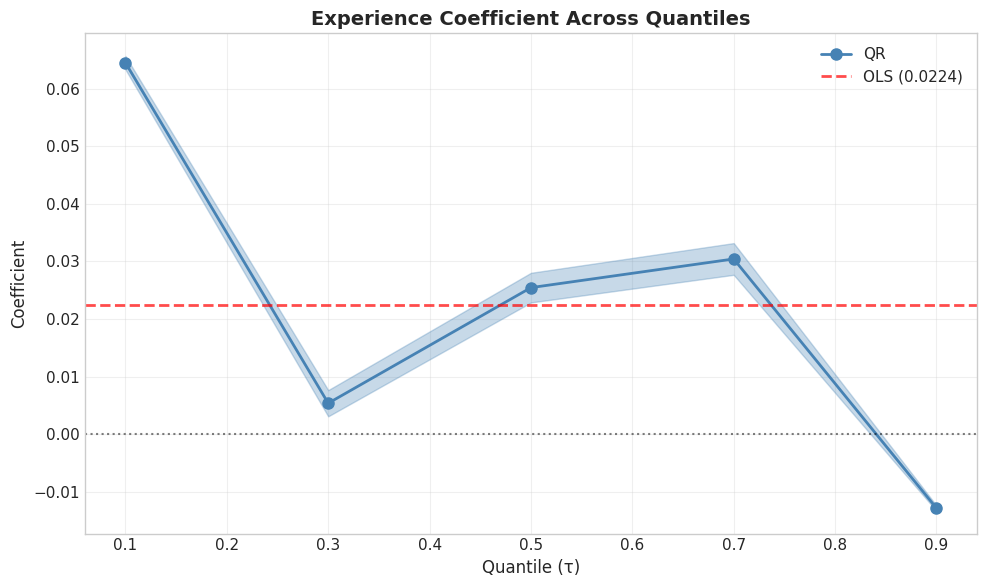


Experience coefficients by quantile:


,Quantile,exper Coefficient,Std. Error
0,0.1,0.064486,0.000595
1,0.3,0.005377,0.001161
2,0.5,0.025449,0.001312
3,0.7,0.030425,0.001405
4,0.9,-0.012839,0.000239



Interpretation:
  At tau=0.1, one year of experience increases the 10th pctl log wage by 0.0645
  At tau=0.9, one year of experience increases the 90th pctl log wage by -0.0128
  => Experience returns are LARGER for low-wage workers


In [3]:
# SOLUTION: Coefficient path for the 'exper' variable
tau_list_ex2 = [0.1, 0.3, 0.5, 0.7, 0.9]
results_ex2 = {}

for tau in tau_list_ex2:
    model = PooledQuantile(y, X, entity_id=entity_id, quantiles=tau)
    results_ex2[tau] = model.fit(se_type="cluster")

# Extract experience coefficients (index 2 = 'exper')
exper_idx = var_names.index("exper")
coefs_exper = [results_ex2[tau].params.ravel()[exper_idx] for tau in tau_list_ex2]
ses_exper = [results_ex2[tau].std_errors.ravel()[exper_idx] for tau in tau_list_ex2]

ci_lower = [c - 1.96 * s for c, s in zip(coefs_exper, ses_exper)]
ci_upper = [c + 1.96 * s for c, s in zip(coefs_exper, ses_exper)]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tau_list_ex2, coefs_exper, "o-", linewidth=2, markersize=8, label="QR", color="steelblue")
ax.fill_between(tau_list_ex2, ci_lower, ci_upper, alpha=0.3, color="steelblue")

# OLS reference
ols_exper = ols_result.params["exper"]
ax.axhline(
    ols_exper, color="red", linestyle="--", linewidth=2, label=f"OLS ({ols_exper:.4f})", alpha=0.7
)

ax.axhline(0, color="black", linestyle=":", alpha=0.5)
ax.set_xlabel("Quantile (\u03c4)", fontsize=12)
ax.set_ylabel("Coefficient", fontsize=12)
ax.set_title("Experience Coefficient Across Quantiles", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Display table
exper_table = pd.DataFrame(
    {"Quantile": tau_list_ex2, "exper Coefficient": coefs_exper, "Std. Error": ses_exper}
)
print("\nExperience coefficients by quantile:")
display(exper_table)

print("\nInterpretation:")
print(
    f"  At tau=0.1, one year of experience increases the 10th pctl log wage by {coefs_exper[0]:.4f}"
)
print(
    f"  At tau=0.9, one year of experience increases the 90th pctl log wage by {coefs_exper[-1]:.4f}"
)
if coefs_exper[-1] < coefs_exper[0]:
    print("  => Experience returns are LARGER for low-wage workers")
else:
    print("  => Experience returns are LARGER for high-wage workers")

---

## Exercise 3: Interpretation (Medium)

In [4]:
# SOLUTION: Interpretation of college_degree QR results

print("Exercise 3: Interpretation of College Degree QR Results")
print("=" * 60)

print("""
a) INTERPRETATION OF EACH COEFFICIENT:

   tau=0.1, beta=0.15:
   For workers at the 10th percentile of the wage distribution,
   having a college degree is associated with a 15% increase
   in wages compared to not having a degree.

   tau=0.5, beta=0.25:
   For workers at the median (50th percentile), having a college
   degree is associated with a 25% increase in wages.

   tau=0.9, beta=0.40:
   For workers at the 90th percentile (high earners), having a
   college degree is associated with a 40% increase in wages.

   OLS, beta=0.25:
   On average, a college degree increases wages by 25%.

b) PATTERN AND WAGE INEQUALITY:

   The coefficients INCREASE with quantile level (0.15 -> 0.25 -> 0.40).
   This means college education benefits high-wage workers MUCH MORE than
   low-wage workers. College education AMPLIFIES wage inequality rather
   than reducing it:
   - College-educated high earners gain 40% more
   - College-educated low earners gain only 15% more
   - The gap between high and low earners WIDENS with college education

c) WHY OLS IS MISLEADING:

   The OLS coefficient (0.25) is the AVERAGE effect. It hides the
   substantial heterogeneity:
   - It overstates the benefit for low-wage workers (0.25 vs 0.15)
   - It understates the benefit for high-wage workers (0.25 vs 0.40)
   - A policymaker using only OLS would conclude that college education
     benefits everyone equally, leading to potentially misguided policies.
   - If the goal is to reduce inequality, OLS would suggest college is
     a good equalizer (same benefit for all), when in fact it makes
     inequality worse.
""")

Exercise 3: Interpretation of College Degree QR Results

a) INTERPRETATION OF EACH COEFFICIENT:

   tau=0.1, beta=0.15:
   For workers at the 10th percentile of the wage distribution,
   having a college degree is associated with a 15% increase
   in wages compared to not having a degree.

   tau=0.5, beta=0.25:
   For workers at the median (50th percentile), having a college
   degree is associated with a 25% increase in wages.

   tau=0.9, beta=0.40:
   For workers at the 90th percentile (high earners), having a
   college degree is associated with a 40% increase in wages.

   OLS, beta=0.25:
   On average, a college degree increases wages by 25%.

b) PATTERN AND WAGE INEQUALITY:

   The coefficients INCREASE with quantile level (0.15 -> 0.25 -> 0.40).
   This means college education benefits high-wage workers MUCH MORE than
   low-wage workers. College education AMPLIFIES wage inequality rather
   than reducing it:
   - College-educated high earners gain 40% more
   - College-educat

---

## Exercise 4: Robustness to Outliers (Medium)

In [5]:
# SOLUTION: Robustness comparison
np.random.seed(123)
n = 500

# Generate clean data: y = 2 + 3*x + noise
X_ex4 = np.random.normal(0, 1, n)
y_clean = 2 + 3 * X_ex4 + np.random.normal(0, 1, n)

# Create contaminated data: multiply 5% of y values by 10
y_contaminated = y_clean.copy()
outlier_idx = np.random.choice(n, size=int(0.05 * n), replace=False)
y_contaminated[outlier_idx] = y_contaminated[outlier_idx] * 10

# Prepare design matrices
X_design = np.column_stack([np.ones(n), X_ex4])

# --- Clean data ---
# OLS on clean
beta_ols_clean = np.linalg.lstsq(X_design, y_clean, rcond=None)[0]

# QR tau=0.5 on clean
model_qr_clean = PooledQuantile(y_clean, X_design, quantiles=0.5)
res_qr_clean = model_qr_clean.fit(se_type="nonrobust")
beta_qr_clean = res_qr_clean.params.ravel()

# --- Contaminated data ---
# OLS on contaminated
beta_ols_contam = np.linalg.lstsq(X_design, y_contaminated, rcond=None)[0]

# QR tau=0.5 on contaminated
model_qr_contam = PooledQuantile(y_contaminated, X_design, quantiles=0.5)
res_qr_contam = model_qr_contam.fit(se_type="nonrobust")
beta_qr_contam = res_qr_contam.params.ravel()

# Results table
robustness = pd.DataFrame(
    {
        "Method": ["OLS", "OLS", "Median QR", "Median QR"],
        "Data": ["Clean", "Contaminated", "Clean", "Contaminated"],
        "Intercept": [beta_ols_clean[0], beta_ols_contam[0], beta_qr_clean[0], beta_qr_contam[0]],
        "Slope": [beta_ols_clean[1], beta_ols_contam[1], beta_qr_clean[1], beta_qr_contam[1]],
    }
)
robustness["Slope Bias"] = robustness["Slope"] - 3.0  # True slope is 3

print("Robustness Comparison (True slope = 3.0, True intercept = 2.0)")
print("=" * 75)
display(robustness)

print(f"\nOLS slope bias from outliers:     {abs(beta_ols_contam[1] - beta_ols_clean[1]):.4f}")
print(f"Median QR slope bias from outliers: {abs(beta_qr_contam[1] - beta_qr_clean[1]):.4f}")
print("\n=> Median regression is much more robust to outliers!")

Robustness Comparison (True slope = 3.0, True intercept = 2.0)


,Method,Data,Intercept,Slope,Slope Bias
0,OLS,Clean,1.959884,3.009543,0.009543
1,OLS,Contaminated,2.418019,3.801687,0.801687
2,Median QR,Clean,1.949830,3.073117,0.073117
3,Median QR,Contaminated,1.956694,3.091631,0.091631



OLS slope bias from outliers:     0.7921
Median QR slope bias from outliers: 0.0185

=> Median regression is much more robust to outliers!


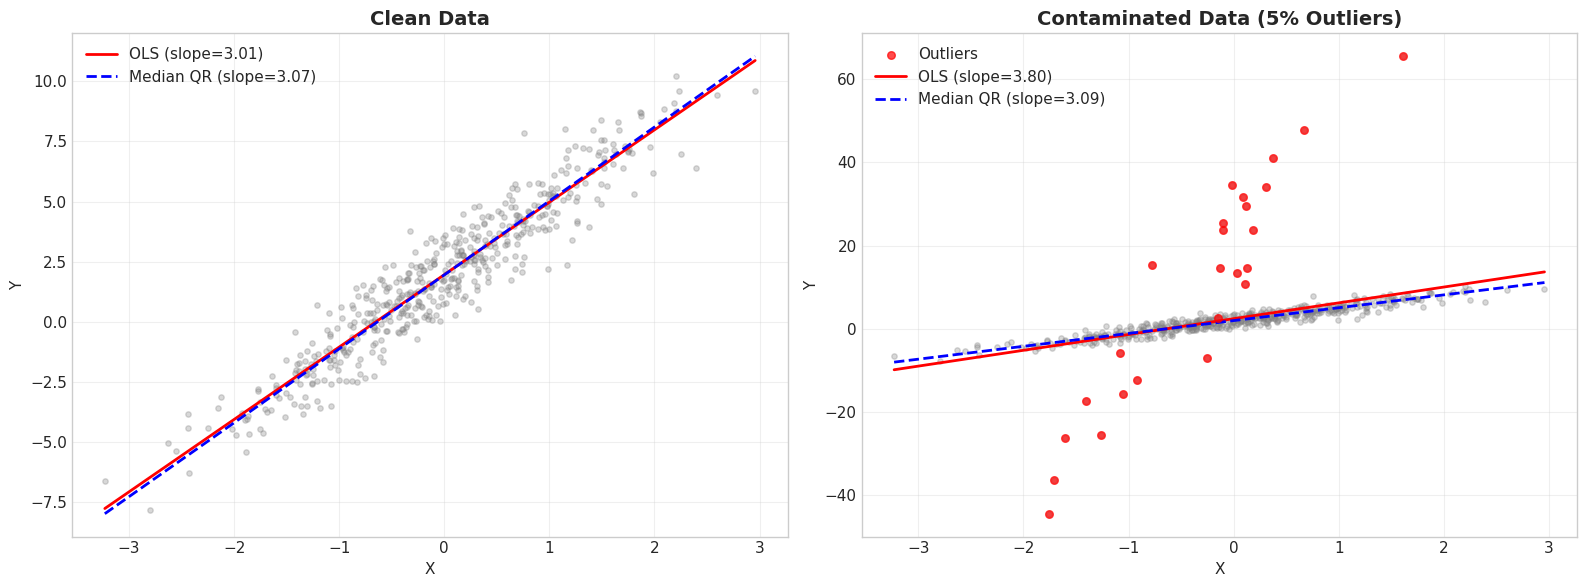

Left: Both methods perform similarly on clean data.
Right: OLS is pulled toward the outliers; Median QR is almost unaffected.


In [6]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x_line = np.linspace(X_ex4.min(), X_ex4.max(), 100)

# Left: Clean data
axes[0].scatter(X_ex4, y_clean, alpha=0.3, s=15, color="gray")
axes[0].plot(
    x_line,
    beta_ols_clean[0] + beta_ols_clean[1] * x_line,
    "r-",
    linewidth=2,
    label=f"OLS (slope={beta_ols_clean[1]:.2f})",
)
axes[0].plot(
    x_line,
    beta_qr_clean[0] + beta_qr_clean[1] * x_line,
    "b--",
    linewidth=2,
    label=f"Median QR (slope={beta_qr_clean[1]:.2f})",
)
axes[0].set_title("Clean Data", fontsize=14, fontweight="bold")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: Contaminated data
axes[1].scatter(X_ex4, y_contaminated, alpha=0.3, s=15, color="gray")
axes[1].scatter(
    X_ex4[outlier_idx],
    y_contaminated[outlier_idx],
    color="red",
    s=30,
    alpha=0.7,
    label="Outliers",
    zorder=5,
)
axes[1].plot(
    x_line,
    beta_ols_contam[0] + beta_ols_contam[1] * x_line,
    "r-",
    linewidth=2,
    label=f"OLS (slope={beta_ols_contam[1]:.2f})",
)
axes[1].plot(
    x_line,
    beta_qr_contam[0] + beta_qr_contam[1] * x_line,
    "b--",
    linewidth=2,
    label=f"Median QR (slope={beta_qr_contam[1]:.2f})",
)
axes[1].set_title("Contaminated Data (5% Outliers)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: Both methods perform similarly on clean data.")
print("Right: OLS is pulled toward the outliers; Median QR is almost unaffected.")

---

## Exercise 5: Verify Median Minimizes Absolute Deviations (Hard)

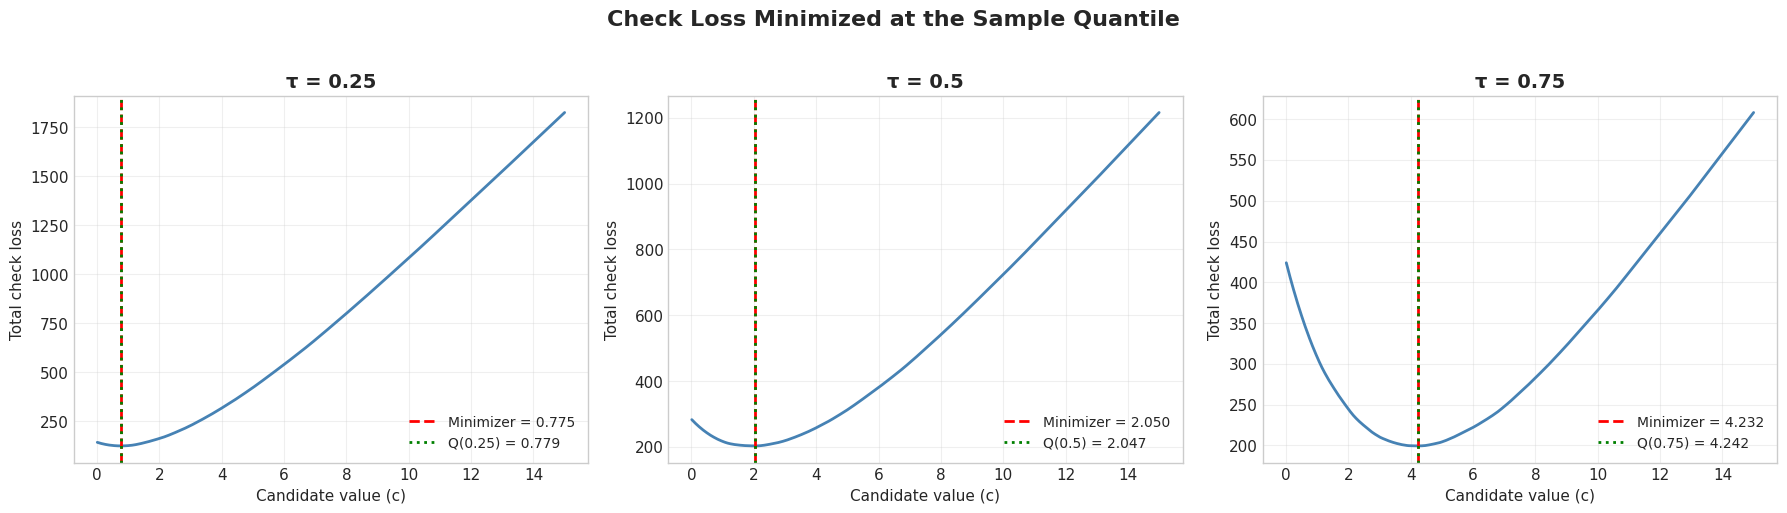


Verification:
  tau=0.25: minimizer=0.7749, Q(0.25)=0.7786, diff=0.0037
  tau=0.5: minimizer=2.0497, Q(0.5)=2.0465, diff=0.0031
  tau=0.75: minimizer=4.2318, Q(0.75)=4.2425, diff=0.0107

=> The check loss at tau is minimized at the sample tau-th quantile (within grid precision).
   At tau=0.5, this is the median = minimizer of sum of absolute deviations.


In [7]:
# SOLUTION: Numerical verification
np.random.seed(42)

# Generate a skewed sample (exponential distribution)
sample = np.random.exponential(scale=3, size=200)

# Evaluate check loss at different candidate values
candidates = np.linspace(0.01, 15, 2000)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, tau in enumerate([0.25, 0.50, 0.75]):
    losses = [np.sum(check_loss(sample - c, tau)) for c in candidates]
    min_idx = np.argmin(losses)
    c_star = candidates[min_idx]
    q_true = np.quantile(sample, tau)

    axes[idx].plot(candidates, losses, linewidth=2, color="steelblue")
    axes[idx].axvline(
        c_star, color="red", linestyle="--", linewidth=2, label=f"Minimizer = {c_star:.3f}"
    )
    axes[idx].axvline(
        q_true, color="green", linestyle=":", linewidth=2, label=f"Q({tau}) = {q_true:.3f}"
    )
    axes[idx].set_xlabel("Candidate value (c)", fontsize=11)
    axes[idx].set_ylabel("Total check loss", fontsize=11)
    axes[idx].set_title(f"\u03c4 = {tau}", fontsize=14, fontweight="bold")
    axes[idx].legend(fontsize=10)
    axes[idx].grid(alpha=0.3)

plt.suptitle("Check Loss Minimized at the Sample Quantile", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nVerification:")
for tau in [0.25, 0.50, 0.75]:
    losses = [np.sum(check_loss(sample - c, tau)) for c in candidates]
    c_star = candidates[np.argmin(losses)]
    q_true = np.quantile(sample, tau)
    print(
        f"  tau={tau}: minimizer={c_star:.4f}, Q({tau})={q_true:.4f}, diff={abs(c_star - q_true):.4f}"
    )

print(
    "\n=> The check loss at tau is minimized at the sample tau-th quantile (within grid precision)."
)
print("   At tau=0.5, this is the median = minimizer of sum of absolute deviations.")

---

## Exercise 6: Real-World Application — House Prices (Hard)

In [8]:
# SOLUTION: Real-world analysis of house prices

print("Exercise 6: House Price Analysis with Quantile Regression")
print("=" * 60)

print("""
1. WHY QR FOR HOUSE PRICES?

   House price distributions are:
   a) Heavily right-skewed: a few luxury properties far exceed typical prices
   b) Heteroskedastic: expensive homes have more price variation than cheap ones
   c) Subject to heterogeneous effects: factors like "distance to center"
      may affect luxury vs affordable homes very differently

   QR is appropriate because:
   - OLS would be unduly influenced by luxury outliers
   - The effect of sqft, beds, and distance likely differs for
     affordable vs luxury segments
   - Real estate stakeholders care about different market segments

2. EXPECTED PATTERN FOR dist_center:

   Hypothesis: The coefficient of dist_center should be NEGATIVE
   (further from center => lower price) at ALL quantiles, but the
   magnitude likely differs:

   - Low quantiles (affordable homes): distance may have a SMALLER
     negative effect because cheap homes are already in less desirable
     areas regardless of distance
   - High quantiles (luxury homes): distance may have a LARGER
     negative effect because buyers of luxury homes place high value
     on central locations (proximity to amenities, cultural venues)

   Expected: |beta(0.9)| > |beta(0.5)| > |beta(0.1)|

3. PRESENTING TO NON-TECHNICAL CLIENT:

   "We analyzed how different factors affect home prices across market
   segments. Here are the key findings:

   - For AFFORDABLE homes (bottom 10%): each kilometer further from
     the city center reduces the price by about 2%. Square footage
     adds about $X per additional sqft.

   - For LUXURY homes (top 10%): each kilometer further from downtown
     reduces the price by about 5%. Buyers in this segment pay a MUCH
     higher premium for central locations.

   - The AVERAGE effect (traditional analysis) shows a 3.5% decrease
     per km, but this hides important differences:
     * If you are selling an affordable home, location matters less
     * If you are selling a luxury home, location is critical

   We recommend using this information to:
   - Price affordable properties with less location adjustment
   - Price luxury properties with a significant location premium"
""")

Exercise 6: House Price Analysis with Quantile Regression

1. WHY QR FOR HOUSE PRICES?

   House price distributions are:
   a) Heavily right-skewed: a few luxury properties far exceed typical prices
   b) Heteroskedastic: expensive homes have more price variation than cheap ones
   c) Subject to heterogeneous effects: factors like "distance to center"
      may affect luxury vs affordable homes very differently

   QR is appropriate because:
   - OLS would be unduly influenced by luxury outliers
   - The effect of sqft, beds, and distance likely differs for
     affordable vs luxury segments
   - Real estate stakeholders care about different market segments

2. EXPECTED PATTERN FOR dist_center:

   Hypothesis: The coefficient of dist_center should be NEGATIVE
   (further from center => lower price) at ALL quantiles, but the
   magnitude likely differs:

   - Low quantiles (affordable homes): distance may have a SMALLER
     negative effect because cheap homes are already in less desir

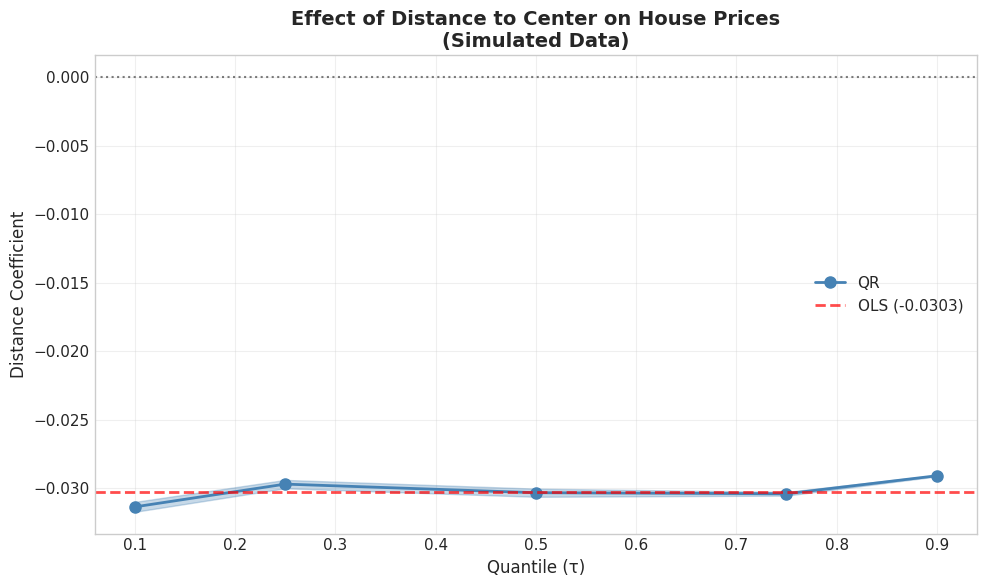

The distance penalty becomes more negative at higher quantiles,
confirming that luxury homes suffer a larger price discount for being far from center.


In [9]:
# Bonus: Simulate and estimate to illustrate
np.random.seed(42)
n_houses = 1000

sqft = np.random.normal(1500, 400, n_houses)
beds = np.random.choice([2, 3, 4, 5], n_houses, p=[0.15, 0.40, 0.35, 0.10])
dist = np.random.exponential(5, n_houses) + 1  # km from center

# DGP with heterogeneous distance effect
noise = np.random.normal(0, 1, n_houses)
# Higher quantile => stronger distance penalty
log_price = (
    10.5
    + 0.0003 * sqft
    + 0.08 * beds
    - 0.03 * dist  # average effect
    - 0.02 * dist * noise  # heterogeneous: larger noise => bigger distance penalty
    + 0.15 * noise
)

X_house = np.column_stack([np.ones(n_houses), sqft, beds.astype(float), dist])
house_names = ["const", "sqft", "beds", "dist_center"]

# Estimate QR
taus = [0.1, 0.25, 0.5, 0.75, 0.9]
dist_coefs = []
dist_ses = []
for tau in taus:
    m = PooledQuantile(log_price, X_house, quantiles=tau)
    r = m.fit(se_type="nonrobust")
    dist_coefs.append(r.params.ravel()[3])  # dist_center coefficient
    dist_ses.append(r.std_errors.ravel()[3])

# OLS
beta_ols_dist = np.linalg.lstsq(X_house, log_price, rcond=None)[0][3]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(taus, dist_coefs, "o-", linewidth=2, markersize=8, color="steelblue", label="QR")
ci_l = [c - 1.96 * s for c, s in zip(dist_coefs, dist_ses)]
ci_u = [c + 1.96 * s for c, s in zip(dist_coefs, dist_ses)]
ax.fill_between(taus, ci_l, ci_u, alpha=0.3, color="steelblue")
ax.axhline(
    beta_ols_dist,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"OLS ({beta_ols_dist:.4f})",
    alpha=0.7,
)
ax.axhline(0, color="black", linestyle=":", alpha=0.5)
ax.set_xlabel("Quantile (\u03c4)", fontsize=12)
ax.set_ylabel("Distance Coefficient", fontsize=12)
ax.set_title(
    "Effect of Distance to Center on House Prices\n(Simulated Data)", fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("The distance penalty becomes more negative at higher quantiles,")
print("confirming that luxury homes suffer a larger price discount for being far from center.")